===== KPI 1: PRODUCTO MÁS VENDIDO =====
Producto: MANZANA
Cantidad vendida: 1974


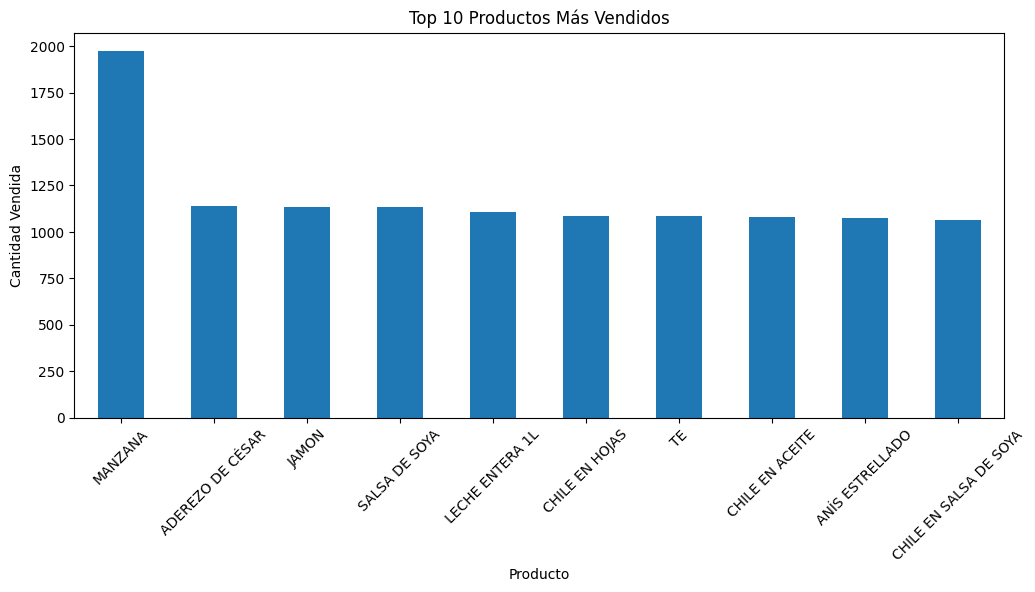


===== KPI 2: PRODUCTOS MENOS VENDIDOS =====
nombre
CHILE EN SALSA             851
ALBAHACA                   888
CHILE EN SALSA DE QUESO    893
LECHE DE ALMENDRAS         902
MAYONESA                   904
AJI MOLIDO                 912
MOSTAZA                    933
CHILE EN POLVO             936
PIMENTÓN                   938
CHILE EN AZUCAR            944
Name: cantidad, dtype: int64


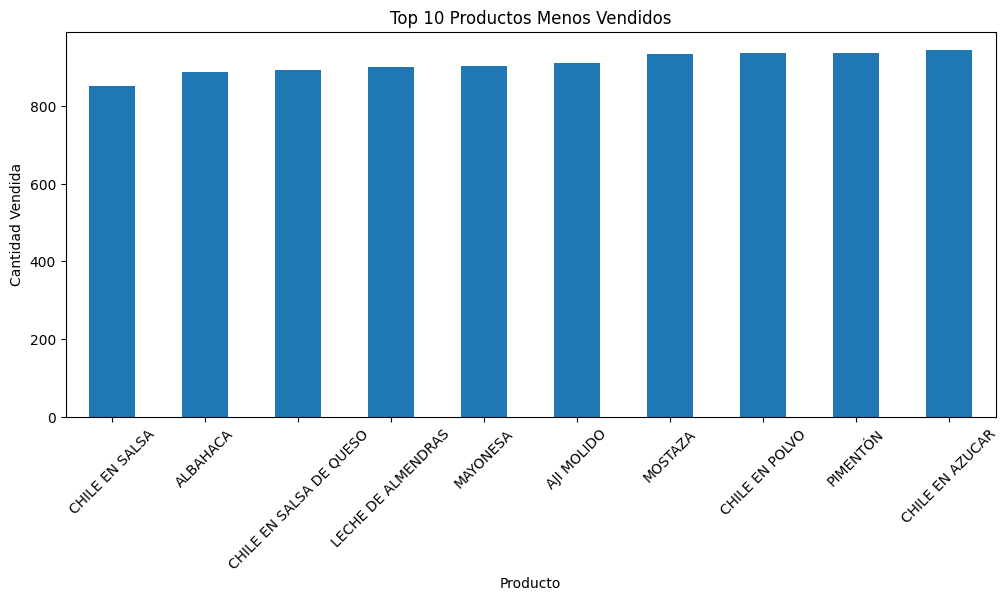


===== KPI 3: MES CON MÁS VENTAS =====
Mes con más ventas: January
Total vendido: $14929.38


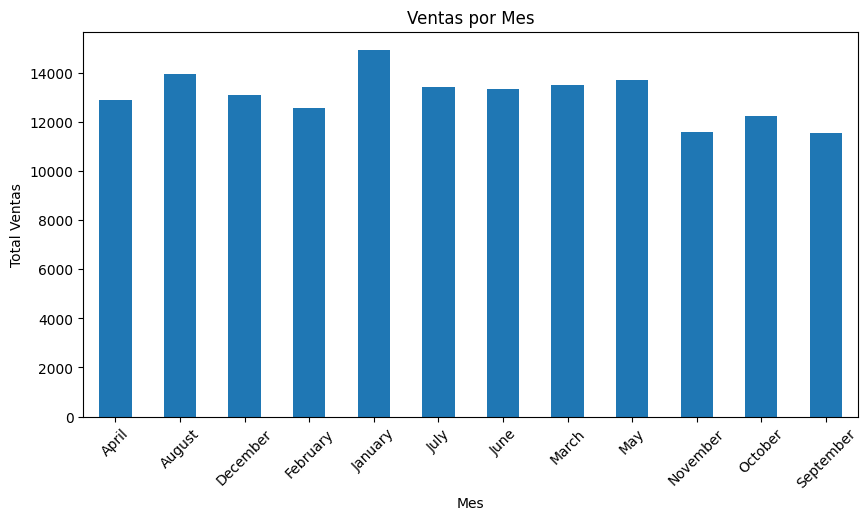

In [9]:
# =========================================
# KPI 1: PRODUCTO MÁS VENDIDO
# KPI 2: PRODUCTOS MENOS VENDIDOS
# KPI 3: MES CON MÁS VENTAS
# =========================================

import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# CARGAR ARCHIVO CSV
# =========================================

df = pd.read_csv('facturas.csv')

# =========================================
# LIMPIEZA DE DATOS
# =========================================

df['fecha'] = pd.to_datetime(df['fecha'])

# Crear columna de mes
df['mes'] = df['fecha'].dt.month_name()

# =========================================
# KPI 1: PRODUCTO MÁS VENDIDO
# =========================================

productos_vendidos = df.groupby('nombre')['cantidad'].sum()

producto_mas_vendido = productos_vendidos.idxmax()
cantidad_mas_vendida = productos_vendidos.max()

print("===== KPI 1: PRODUCTO MÁS VENDIDO =====")
print(f"Producto: {producto_mas_vendido}")
print(f"Cantidad vendida: {cantidad_mas_vendida}")

# GRÁFICO PRODUCTOS MÁS VENDIDOS
plt.figure(figsize=(12,5))
productos_vendidos.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Productos Más Vendidos')
plt.xlabel('Producto')
plt.ylabel('Cantidad Vendida')
plt.xticks(rotation=45)
plt.show()

# =========================================
# KPI 2: PRODUCTOS MENOS VENDIDOS
# =========================================

productos_menos = productos_vendidos.sort_values().head(10)

print("\n===== KPI 2: PRODUCTOS MENOS VENDIDOS =====")
print(productos_menos)

# GRÁFICO PRODUCTOS MENOS VENDIDOS
plt.figure(figsize=(12,5))
productos_menos.plot(kind='bar')
plt.title('Top 10 Productos Menos Vendidos')
plt.xlabel('Producto')
plt.ylabel('Cantidad Vendida')
plt.xticks(rotation=45)
plt.show()

# =========================================
# KPI 3: MES CON MÁS VENTAS
# =========================================

ventas_mes = df.groupby('mes')['totalFactura'].sum()

mes_mas_ventas = ventas_mes.idxmax()
valor_mes = ventas_mes.max()

print("\n===== KPI 3: MES CON MÁS VENTAS =====")
print(f"Mes con más ventas: {mes_mas_ventas}")
print(f"Total vendido: ${valor_mes:.2f}")

# GRÁFICO DE VENTAS POR MES
plt.figure(figsize=(10,5))
ventas_mes.plot(kind='bar')
plt.title('Ventas por Mes')
plt.xlabel('Mes')
plt.ylabel('Total Ventas')
plt.xticks(rotation=45)
plt.show()